In [401]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tools.tools import *
from tools.bag_to_df import bag_topic_to_dataframe
import pandas as pd
from scipy.spatial.transform import Rotation as R
from tools.signal_properties import compare_signals


%load_ext autoreload
%autoreload 2

REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_12-10_16_52"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [402]:
print_bag_topics(REAL_BAG_PATH)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

# Read data

In [403]:
from tools.data import Nucleus

xyz_post = np.array([23.5, 4.5, 0])
rpy_post = np.array([0, 0, -2.1])
ins_data = Nucleus(REAL_BAG_PATH, xyz_post, rpy_post)

nucleus_alitmeter = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/altimeter")
nucleus_bottomtrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/bottomtrack")
nucleus_magnetometer = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/magnetometer")
nucleus_watertrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/watertrack")


imu_sensor = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/imu")
nucleus_imu = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/imu")

# A50
dvl_a50_position = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_position")
dvl_a50_velocity = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_velocity")

# SIM
sim_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl")
sim_a50 = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl_a50")
sim_gt = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")
sim_gt_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth_dvl")
sim_ins = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ins")
sim_imu = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/imu")
print("")

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


# Normalize time

Use the first element of ground truth running at 100 Hz as the starting point of time. Topics spawn after some time

In [404]:
imu = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/imu")
t0_real = imu["t"][0]

# Get t0 of simulation
t0_sim = sim_gt["t"].iloc[0] - 0.4


def set_t0(df: pd.DataFrame, t_0):
    df["t"] -= t_0

# Subtract t0
set_t0(sim_gt, t0_sim)
set_t0(sim_gt_dvl, t0_sim)
set_t0(sim_a50, t0_sim)
set_t0(sim_dvl, t0_sim)
set_t0(sim_ins, t0_sim)
set_t0(sim_imu, t0_sim)

ins_data.set_t0(t0_real)
set_t0(nucleus_alitmeter, t0_real)
set_t0(nucleus_bottomtrack, t0_real)
set_t0(nucleus_magnetometer, t0_real)
set_t0(nucleus_watertrack, t0_real)
set_t0(dvl_a50_position, t0_real)
set_t0(dvl_a50_velocity, t0_real)
set_t0(imu_sensor, t0_real)
set_t0(nucleus_imu, t0_real)


# Sway Velocity

{'rmse': 0.01311169761653595, 'corr': 0.9208200325718718, 'mean_error': -0.0001107061559486513, 'var_signal1': 0.0011307088381223376, 'var_signal2': 0.0009790450915170906, 'var_difference': 0.00015166374660524704, 'var_ratio_s1_over_s2': 1.154909868727532, 'cv_signal1': 0.35047771121916005, 'cv_signal2': 0.32650344384412183, 'kurtosis_signal1': 1.5502801059543359, 'kurtosis_signal2': 0.931407168142341, 'kurtosis_difference': 0.6188729378119948}
{'rmse': 0.030109865237531733, 'corr': 0.4304753193581465, 'mean_error': 0.00212050786249302, 'var_signal1': 0.0010631161332887923, 'var_signal2': 0.0004044251974366435, 'var_difference': 0.0006586909358521488, 'var_ratio_s1_over_s2': 2.628708943031024, 'cv_signal1': 0.33540836478840097, 'cv_signal2': 0.2024561822639328, 'kurtosis_signal1': 1.530390783429258, 'kurtosis_signal2': 0.9658700025634435, 'kurtosis_difference': 0.5645207808658146}
{'rmse': 0.0269041178169521, 'corr': 0.48312441914355486, 'mean_error': 0.0020561633826189037, 'var_signal

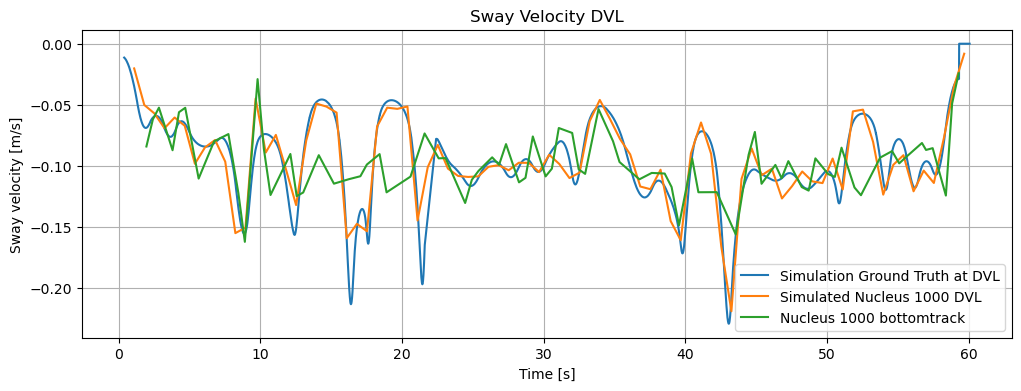

In [405]:
# Remove outlier value of dvl bottomtrack
nucleus_bottomtrack = nucleus_bottomtrack[nucleus_bottomtrack["dvl_velocity_xyz.x"] > 0]
nucleus_vel_xyz = np.array([nucleus_bottomtrack])

t_gt, data_gt = sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values
t_sim_dvl, data_sim_dvl = sim_dvl["t"].values, sim_dvl["velocity.y"].values
t_bt, data_bt = nucleus_bottomtrack["t"].values, -nucleus_bottomtrack["dvl_velocity_xyz.x"].values

# Remove lag from nucleus bottomtrack
lag_sec = get_signal_lag(t_bt, data_bt, t_gt, data_gt)
t_bt += lag_sec

plt.figure(figsize=(12, 4))

# --- GROUND THRUTH ---
plt.plot(t_gt, data_gt, label="Simulation Ground Truth at DVL")

# --- SIMULATED NUCLEUS ---
plt.plot(t_sim_dvl, data_sim_dvl, label="Simulated Nucleus 1000 DVL")

# --- NUCLEUS BOTTOMTRACK ---
plt.plot(t_bt, data_bt, label="Nucleus 1000 bottomtrack")

plt.title("Sway Velocity DVL")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.legend()
plt.grid()

comp_simulated = compare_signals(t_gt, data_gt,
                        t_sim_dvl, data_sim_dvl)

comp_real      = compare_signals(t_gt, data_gt ,
                        t_bt, data_bt)

comp_real_vs_sim = compare_signals(t_sim_dvl, data_sim_dvl,
                        t_bt, data_bt)

print(comp_simulated)
print(comp_real)
print(comp_real_vs_sim)

# DVL A50 velovity comparison

{'rmse': 0.03235534350811751, 'corr': 0.527060082929897, 'mean_error': -0.0012368374842766337, 'var_signal1': 0.001373457061542426, 'var_signal2': 0.0007243037281941042, 'var_difference': 0.0006491533333483217, 'var_ratio_s1_over_s2': 1.8962446389263328, 'cv_signal1': 0.39010204670598975, 'cv_signal2': 0.2870267204129978, 'kurtosis_signal1': 1.1278816492687511, 'kurtosis_signal2': 1.5425335919975813, 'kurtosis_difference': -0.4146519427288302}


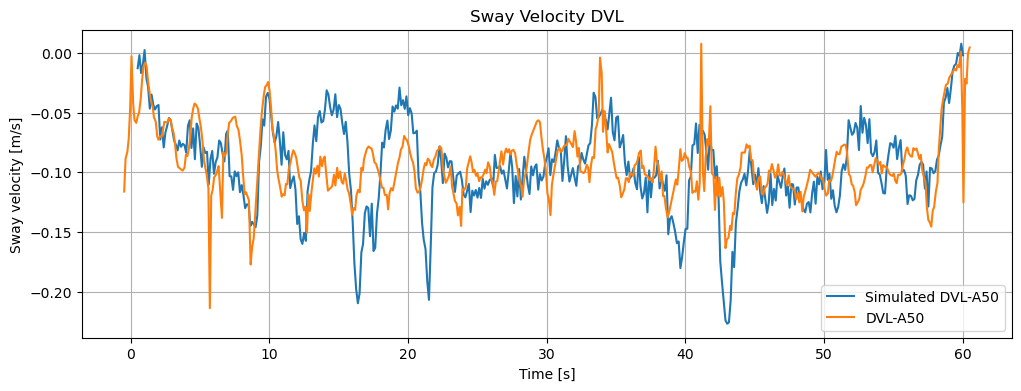

In [406]:
# Remove outlier value of dvl bottomtrack

t1, data1 = sim_a50["t"].values, sim_a50["velocity.y"].values
t2, data2 = dvl_a50_velocity["t"].values, -dvl_a50_velocity["velocity.x"].values

lag_sec = get_signal_lag(t1, data1, t2, data2)
t2 -= lag_sec

plt.figure(figsize=(12, 4))

# --- SIMULATED A50 ---
plt.plot(t1, data1, label="Simulated DVL-A50")

# --- REAL A50 ---
plt.plot(t2, data2, label="DVL-A50")


plt.title("Sway Velocity DVL")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.legend()
plt.grid()

comp_real_vs_sim = compare_signals(t1, data1,
                        t2, data2)

print(comp_real_vs_sim)

Diskusjon: Erroren vil forplante seg gjennom rekonstrueringen av signalet

# Position comparison

{'rmse': 0.005949402696547908, 'corr': 0.9975416217406463, 'mean_error': -4.6743113718875404e-05, 'var_signal1': 0.006966053339121217, 'var_signal2': 0.007117013921000629, 'var_difference': -0.00015096058187941217, 'var_ratio_s1_over_s2': 0.978788775242667, 'cv_signal1': 0.0034394678298701347, 'cv_signal2': 0.0034765295491899096, 'kurtosis_signal1': -0.8733803922377295, 'kurtosis_signal2': -0.8957697905836488, 'kurtosis_difference': 0.022389398345919354}
{'rmse': 0.0131744105857853, 'corr': 0.9999732855956202, 'mean_error': 0.004458800465934646, 'var_signal1': 2.873787405368688, 'var_signal2': 2.8754819660719653, 'var_difference': -0.0016945607032772259, 'var_ratio_s1_over_s2': 0.9994106863742247, 'cv_signal1': 145.10452842059055, 'cv_signal2': 234.73538841417442, 'kurtosis_signal1': -1.2194370611406997, 'kurtosis_signal2': -1.2175859500973525, 'kurtosis_difference': -0.001851111043347231}
{'rmse': 0.009499656299912817, 'corr': 0.9834410287807325, 'mean_error': 0.0003349502442831516, '

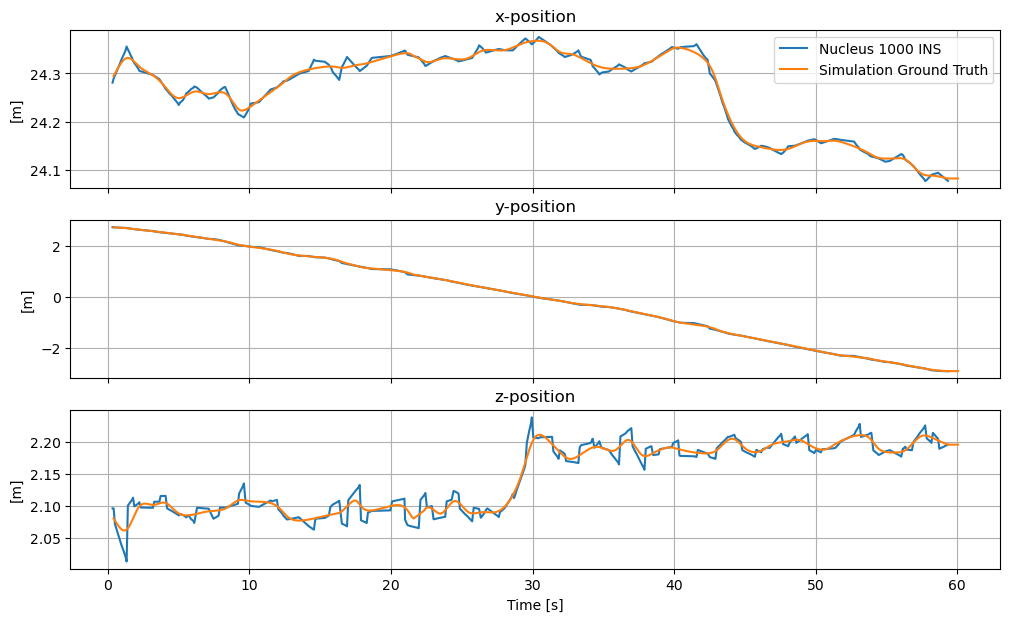

In [407]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ins_data.t, ins_data.x, label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values, label="Simulation Ground Truth")
axes[0].set_title("x-position")
axes[0].set_ylabel("[m]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ins_data.t, ins_data.y, label="Nucleus 1000 INS")
axes[1].plot(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values, label="Simulation Ground Truth")
axes[1].set_title("y-position")
axes[1].set_ylabel("[m]")
# axes[1].legend()
axes[1].grid(True)

axes[2].plot(ins_data.t, ins_data.z, label="Nucleus 1000 INS")
axes[2].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
axes[2].set_title("z-position")
axes[2].set_ylabel("[m]")
axes[2].set_xlabel("Time [s]")
# axes[2].legend()
axes[2].grid(True)

comp_x = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values,
                        ins_data.t, ins_data.x)

comp_y = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values,
                        ins_data.t, ins_data.y)

comp_z = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values,
                        ins_data.t, ins_data.z)

print(comp_x)
print(comp_y)
print(comp_z)

# Velocity comparison
Diskuter hvor god banen som simuleres er i forhold til ground trurth

# Velocity comparison using Nucleus frame directly

{'rmse': 0.019561436335330425, 'corr': 0.7233777058066988, 'mean_error': -0.0016309429523492555, 'var_signal1': 0.0003161647522525821, 'var_signal2': 0.0007849238024846342, 'var_difference': -0.0004687590502320521, 'var_ratio_s1_over_s2': 0.40279674441236146, 'cv_signal1': 149.96471930795974, 'cv_signal2': 18.52483224557853, 'kurtosis_signal1': 4.35545023861169, 'kurtosis_signal2': -0.13259781696144435, 'kurtosis_difference': 4.488048055573135}
{'rmse': 0.03357242442849419, 'corr': 0.40338146613294096, 'mean_error': 0.001457087765662597, 'var_signal1': 0.0011408636343538665, 'var_signal2': 0.0007127385760673894, 'var_difference': 0.0004281250582864771, 'var_ratio_s1_over_s2': 1.6006761422241271, 'cv_signal1': 0.3534362858606842, 'cv_signal2': 0.27516155197980463, 'kurtosis_signal1': 1.4156527674446968, 'kurtosis_signal2': 0.840700507337778, 'kurtosis_difference': 0.5749522601069188}
{'rmse': 0.0175990525554707, 'corr': 0.6250945694073756, 'mean_error': -0.002430185675423525, 'var_signa

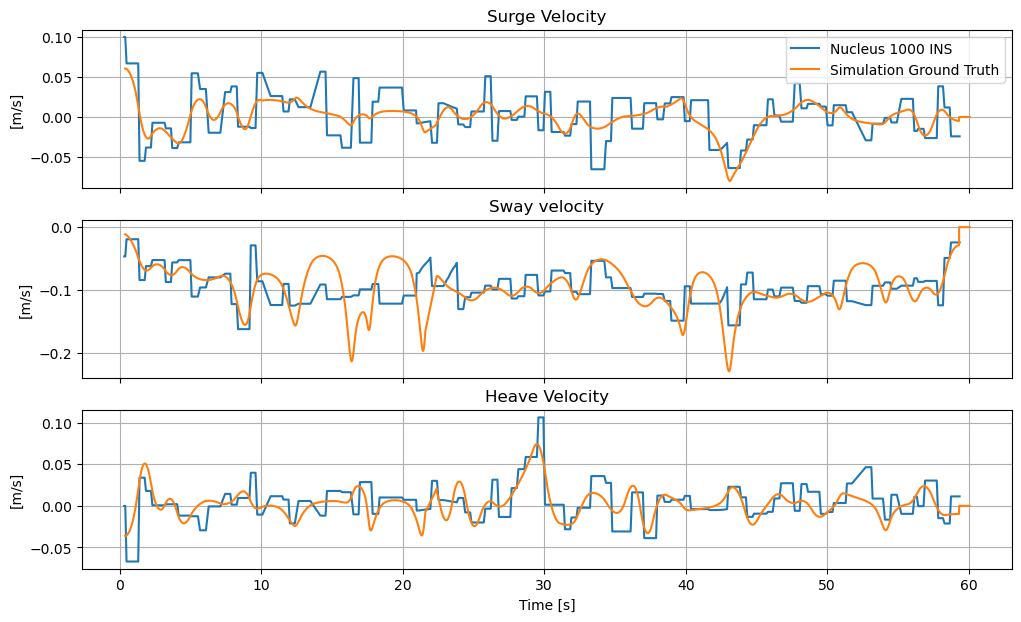

In [408]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

nucleus_ins = ins_data.df_ins

axes[0].plot(nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values, label="Nucleus 1000 INS")
axes[0].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Surge Velocity")
axes[0].set_ylabel("[m/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)
axes[1].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values)
axes[1].set_title("Sway velocity")
axes[1].set_ylabel("[m/s]")
axes[1].grid(True)


axes[2].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)
axes[2].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values)
axes[2].set_title("Heave Velocity")
axes[2].set_ylabel("[m/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_surge = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.x"].values,
                        nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values)

comp_sway = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)

comp_heave = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)

print(comp_surge)
print(comp_sway)
print(comp_heave)

# Angular velocity comparison

{'rmse': 0.029111144678575642, 'corr': 0.1658905139712281, 'mean_error': -0.0009778635533239082, 'var_signal1': 0.00031616483795049124, 'var_signal2': 0.0006856618625009084, 'var_difference': -0.0003694970245504172, 'var_ratio_s1_over_s2': 0.46110897403174783, 'cv_signal1': 149.95515470263817, 'cv_signal2': 30.473075045821115, 'kurtosis_signal1': 4.355469085847537, 'kurtosis_signal2': 11.165715252371639, 'kurtosis_difference': -6.810246166524101}
{'rmse': 0.10429609881486751, 'corr': 0.009091660632326812, 'mean_error': -0.09622665837724875, 'var_signal1': 0.0011408631259712506, 'var_signal2': 0.0004924928605012906, 'var_difference': 0.0006483702654699599, 'var_ratio_s1_over_s2': 2.3165069333391095, 'cv_signal1': 0.3534362590673507, 'cv_signal2': 33.616326750079146, 'kurtosis_signal1': 1.4156566698057098, 'kurtosis_signal2': 8.685947808963212, 'kurtosis_difference': -7.270291139157502}
{'rmse': 0.08200364070510878, 'corr': -0.026822134022595645, 'mean_error': 0.0004939189190502631, 'var

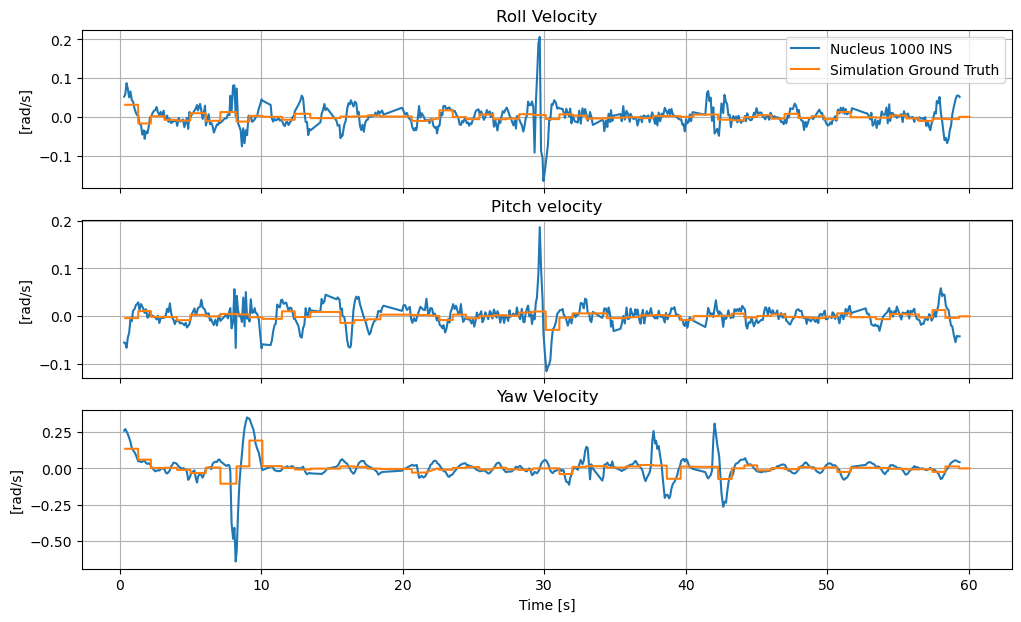

In [409]:
rpy_vel = np.column_stack((np.deg2rad(nucleus_ins["turnRate.x"].values), np.deg2rad(nucleus_ins["turnRate.z"].values), np.deg2rad(-nucleus_ins["turnRate.y"].values)))


fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ins_data.t, rpy_vel[:,0], label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Roll Velocity")
axes[0].set_ylabel("[rad/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ins_data.t, rpy_vel[:,1])
axes[1].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.y"].values)
axes[1].set_title("Pitch velocity")
axes[1].set_ylabel("[rad/s]")
axes[1].grid(True)

axes[2].plot(ins_data.t, rpy_vel[:,2])
axes[2].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.z"].values)
axes[2].set_title("Yaw Velocity")
axes[2].set_ylabel("[rad/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_roll = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.x"].values,
                        ins_data.t, rpy_vel[:,0])

comp_pitch = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.y"].values,
                        ins_data.t, rpy_vel[:,1])

comp_yaw = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.z"].values,
                        ins_data.t, rpy_vel[:,2])

print(comp_roll)
print(comp_pitch)
print(comp_yaw)

# Beams

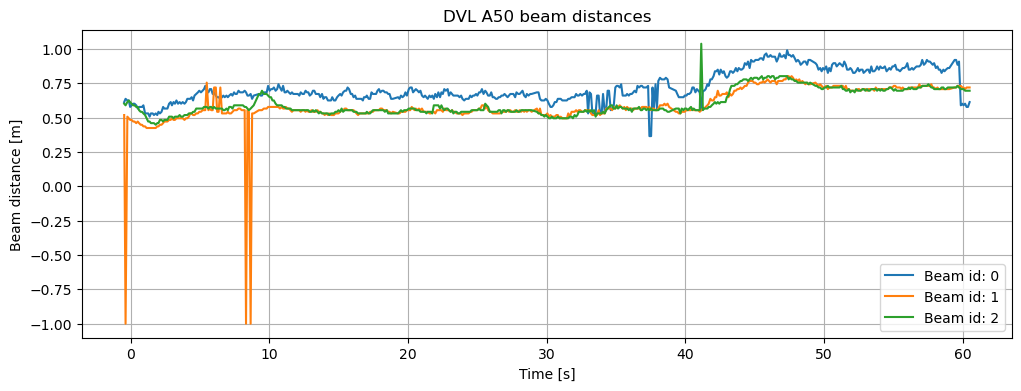

In [410]:
plt.figure(figsize=(12, 4))

# --- DVL-A50 ---
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.0.distance"].values, label="Beam id: 0")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.1.distance"].values, label="Beam id: 1")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.2.distance"].values, label="Beam id: 2")

plt.title("DVL A50 beam distances")
plt.xlabel("Time [s]")
plt.ylabel("Beam distance [m]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# INS Linear velocity 
# TODO: Fjern konstant g!

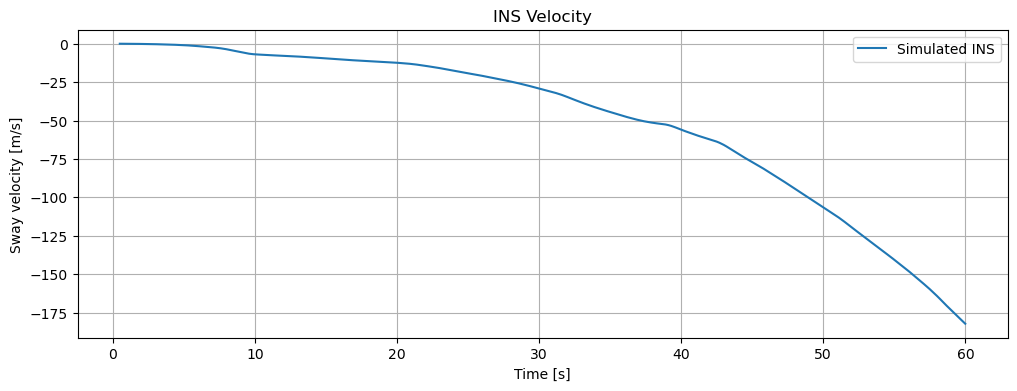

In [411]:
plt.figure(figsize=(12, 4))

plt.plot(sim_ins["t"].values, -sim_ins["pose.north"].values, label="Simulated INS")

# plt.plot(nucleus_ins["t"].values, nucleus_ins["velocityNed.x"].values, label="Nucleus 1000 INS")

# plt.plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values-0.1, label="Simulation Ground Truth")

plt.title("INS Velocity")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# Net Distance

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


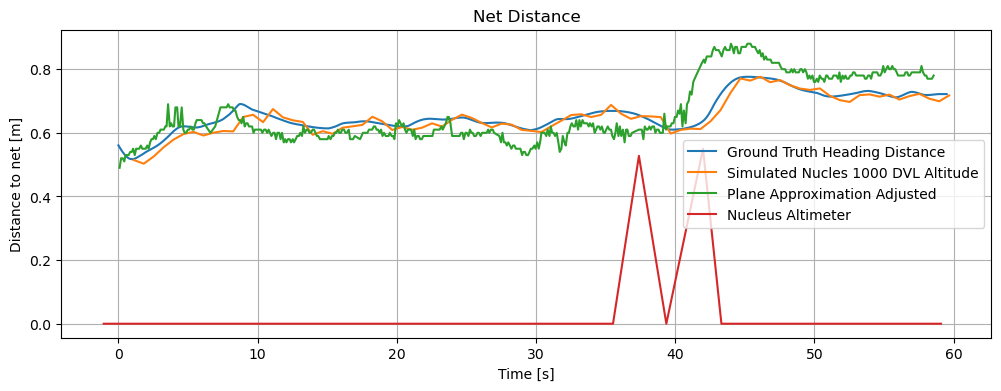

In [412]:
heading_dist_gt = get_profiler_data(SIM_BAG_PATH, "/heading_distance_ground_truth")
plane_approximation = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/navigation/plane_approximation")
normalize_time(plane_approximation)


# Remove outliers and bias
plane_approx_copy = plane_approximation.copy()
plane_approx_copy["diff"] = plane_approx_copy["NetDistance"].diff()
plane_approx_copy = plane_approx_copy[abs(plane_approx_copy["diff"]) <= 0.1]

# plane_approx_copy["NetDistance"] += (np.mean(heading_dist_gt["ranges"]) - plane_approx_copy["NetDistance"].mean())

dist_dvl_imu = 0.178

plt.figure(figsize=(12, 4))
plt.plot(heading_dist_gt["time"], np.array(heading_dist_gt["ranges"]) + dist_dvl_imu, label="Ground Truth Heading Distance")
plt.plot(sim_dvl["t"].values, sim_dvl["altitude"].values + dist_dvl_imu, label="Simulated Nucles 1000 DVL Altitude")
# plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["altitude"].values, label="DVL-A50 Altitude")

# plt.plot(plane_approximation["t"].values, plane_approximation["NetDistance"].values, label="Plane Approximation")
plt.plot(plane_approx_copy["t"].values, plane_approx_copy["NetDistance"].values, label="Plane Approximation Adjusted")


plt.plot(nucleus_alitmeter["t"].values, nucleus_alitmeter["altimeter_distance"].values, label="Nucleus Altimeter")


plt.title("Net Distance")
plt.xlabel("Time [s]")
plt.ylabel("Distance to net [m]")
plt.legend()
plt.grid()

Liten avvik i starten er mest sannsynlig på grunn av vinkelen på roven. Siden dvl har en vinkel på 4 beams.

# Pressure

In [413]:
# Read csv
real_depth_df = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/depth_temperature")
sim_depth_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/pressure")
sim_depth_gt_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")

set_t0(real_depth_df, t0_real)
set_t0(sim_depth_df, t0_sim)
set_t0(sim_depth_gt_df, t0_sim)

RHO = 1031 # [kg/m^3]
g = 9.81

# get array of data
depth_real = real_depth_df["depth"].values
depth_sim = (sim_depth_df["fluid_pressure"].values) / (RHO * g)
sim_depth_gt = sim_depth_gt_df["pose.pose.position.z"].values

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


{'rmse': 0.014739869895938798, 'corr': 0.9568116213358311, 'mean_error': 0.0012304261894735787, 'var_signal1': 0.002473949501686398, 'var_signal2': 0.0025215741520247543, 'var_difference': -4.76246503383561e-05, 'var_ratio_s1_over_s2': 0.9811131271709321, 'cv_signal1': 0.023181960096758276, 'cv_signal2': 0.02341745728548188, 'kurtosis_signal1': -1.7811728694283702, 'kurtosis_signal2': -1.8190469656889021, 'kurtosis_difference': 0.03787409626053195}


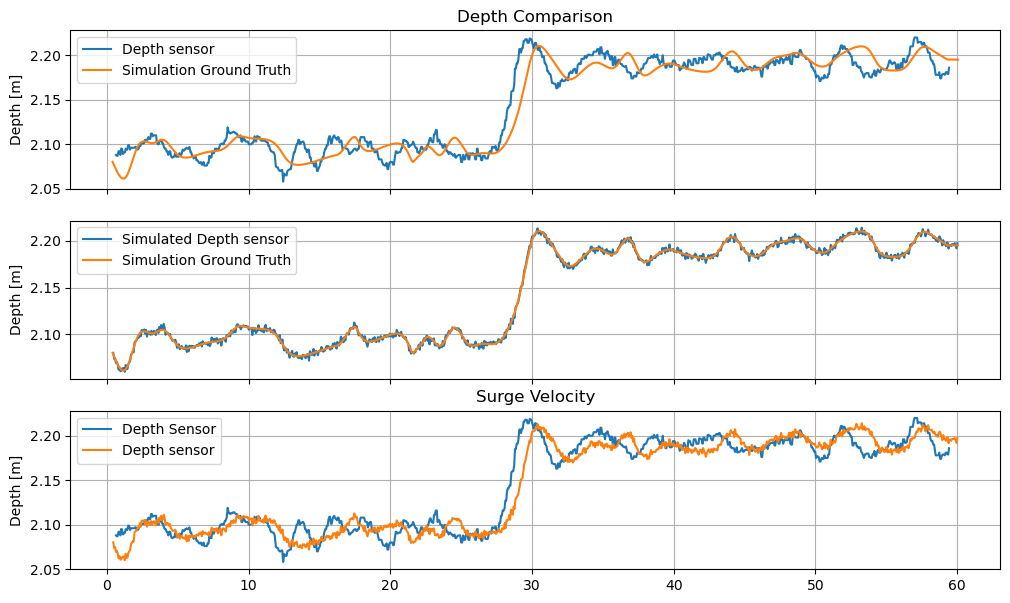

In [414]:
# Remove offset
real_depth_df["depth"] -= real_depth_df["depth"].mean()
real_depth_df["depth"] += sim_gt["pose.pose.position.z"].mean()


fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(real_depth_df["t"].values, real_depth_df["depth"].values, label="Depth sensor")
axes[0].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
# axes[0].plot(nucleus_ins["t"].values, xyz_transformed[:,2], label="Nucleus INS Position")
axes[0].set_title("Depth Comparison")
axes[0].set_ylabel("Depth [m]")
axes[0].legend()
axes[0].grid(True)


axes[1].plot(sim_depth_df["t"].values, depth_sim, label="Simulated Depth sensor")
axes[1].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
# axes[1].set_title("Surge Velocity")
axes[1].set_ylabel("Depth [m]")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(real_depth_df["t"].values, real_depth_df["depth"].values, label="Depth Sensor")
axes[2].plot(sim_depth_df["t"].values, depth_sim, label="Depth sensor")
axes[2].set_title("Surge Velocity")
axes[2].set_ylabel("Depth [m]")
axes[2].legend()
axes[2].grid(True)


comp_depth = compare_signals(real_depth_df["t"].values, real_depth_df["depth"].values,
                        sim_depth_df["t"].values, depth_sim)

print(comp_depth)

Comparing gague pressure

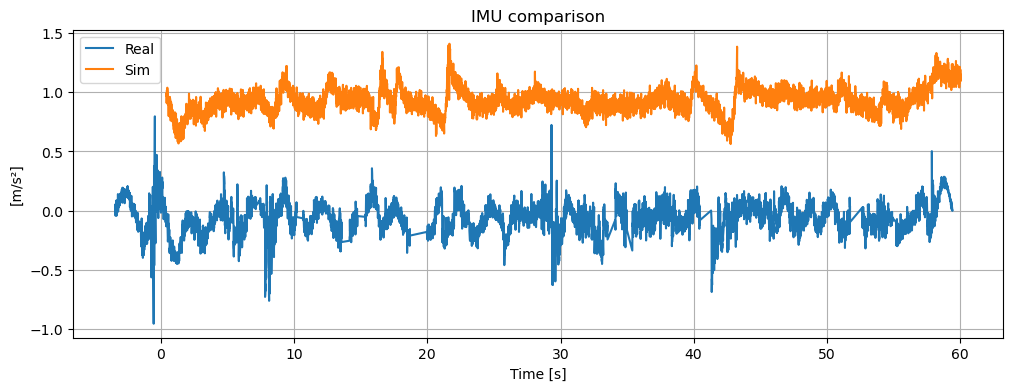

In [415]:
# IMU Comparison
plt.figure(figsize=(12, 4))

# plt.plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.y"].values, label="Real")
# plt.plot(sim_imu["t"].values, -sim_imu["linear_acceleration.z"].values, label="Sim")



# plt.plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.y"].values, label="Real")
# plt.plot(sim_imu["t"].values, -sim_imu["linear_acceleration.z"].values, label="Sim")


plt.plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.z"].values, label="Real")
plt.plot(sim_imu["t"].values, sim_imu["linear_acceleration.y"].values, label="Sim")

plt.legend()


plt.title("IMU comparison")
plt.xlabel("Time [s]")
plt.ylabel("[m/s²]")

# plt.xlim((10, 11))
# plt.ylim((9.6, 10.2))

plt.legend()
plt.grid()

Simulerer ikke dorpouts

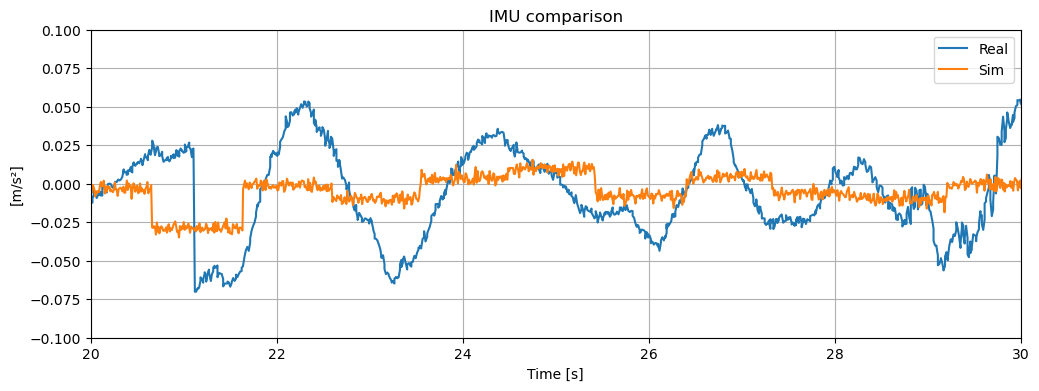

In [417]:
# IMU Comparison
plt.figure(figsize=(12, 4))


# plt.plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.y"].values, label="Real")
# plt.plot(sim_imu["t"].values, -sim_imu["linear_acceleration.z"].values, label="Sim")


# plt.plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.z"].values, label="Real")
# plt.plot(sim_imu["t"].values, sim_imu["linear_acceleration.y"].values, label="Sim")

plt.plot(nucleus_imu["t"].values, -nucleus_imu["gyroscope.y"].values, label="Real")
plt.plot(sim_imu["t"].values, sim_imu["angular_velocity.z"].values, label="Sim")

plt.legend()


plt.title("IMU comparison")
plt.xlabel("Time [s]")
plt.ylabel("[m/s²]")

plt.xlim((20, 30))
plt.ylim((-0.1, 0.1))

plt.legend()
plt.grid()